# DICOM I/O

`imfusion-sdk-dicom` extends the ImFusion Python SDK with DICOM support.

There are two ways to use this functionality:

- Generic loading through `imfusion.io.load()`: After installing the `imfusion-sdk-dicom` package, the generic loader can read DICOM files and folders just like other supported image formats.
- DICOM-specific functionality through `imfusion.dicom`: This submodule provides some extra IO routines specific to DICOM. For example, IO from/to DICOM RTStructuredSet and DICOM Seg.

## Notebook bootstrap


In [1]:
import sys
from pathlib import Path

shared_dir = next(path / "shared" for path in [Path.cwd(), *Path.cwd().parents] if (path / "shared").is_dir())
if str(shared_dir) not in sys.path:
    sys.path.append(str(shared_dir))

from demo_utils import unzip_folder, mpr_plot



## Loading DICOM images with `imfusion.io.load`

Since `imfusion-sdk-dicom` is installed and loaded, the generic `imfusion.io.load()` function can read DICOM files and folders.


In [2]:
import imfusion

unzipped_folder = unzip_folder("../shared/data/pet-ct-rtstruct.zip")
pet, *_ = imfusion.io.load("../shared/data/pet-ct-rtstruct/pet")

[DICOM] Detected different rescale values per frame, rescale will be burned into pixel data!
[DICOM] Detected frame with shift/scale pair which exceeds the value range. Casting all frames to Float.


## Loading RT Structure Sets with `imfusion.dicom.load_file`
RT Structure Sets are DICOM-specific objects. Here we load one explicitly through `imfusion.dicom` and convert it to a labelmap on the PET image grid.


In [3]:
rtstructs = imfusion.dicom.load_file('../shared/data/pet-ct-rtstruct/uterus-rtstruct/1-1.dcm')
# rtstructs are represented as PointClouds
print("rtstruct", rtstructs)
# Convert them to labelmaps, by default, each different set is converted to a separate mask
# Each mask has pixel values specified by the rtstruct label tag, and some background 
mask, *_ = imfusion.dicom.rtstruct_to_labelmap(rtstructs, pet)
print("mask", mask)
# Access the LabelDataComponent to get more information about the specific mask
ldc = mask.components.label
print(ldc.label_configs())
ldc = mask.components.label
print(ldc)
ldc.remove_label(0)  # We don't care about the background here
print(ldc)
label_name = list(ldc.label_configs().values())[0].name
print(label_name)
tumor_mask = mask
assert tumor_mask is not None

rtstruct [<imfusion.PointCloud object at 0x7a67e2e0aff0>]
mask imfusion.SharedImageSet(size: 1, [imfusion.SharedImage(UBYTE width: 192 height: 192 slices: 227 spacing: 3.64583x3.64583x3.27 mm)])
{0: LabelConfig(name="Background", color=(0.00, 0.00, 0.00, 1.00)), 1: LabelConfig(name="UTERUS - 1", color=(1.00, 1.00, 0.00, 1.00))}
<LabelDataComponent
	0: LabelConfig(name="Background", color=(0.00, 0.00, 0.00, 1.00))
	1: LabelConfig(name="UTERUS - 1", color=(1.00, 1.00, 0.00, 1.00))
>
<LabelDataComponent 1: LabelConfig(name="UTERUS - 1", color=(1.00, 1.00, 0.00, 1.00))>
UTERUS - 1


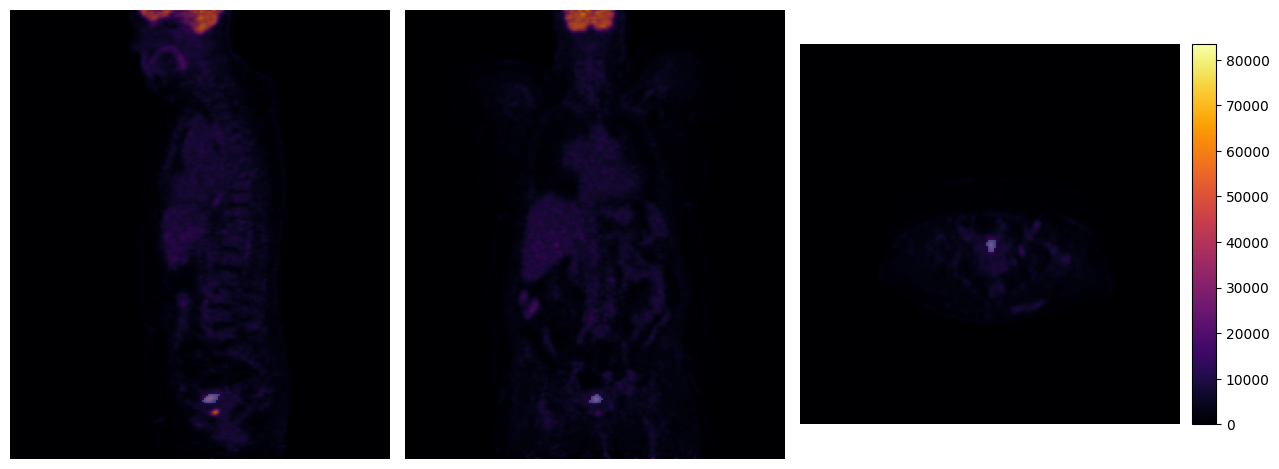

In [4]:
mpr_plot(pet[0], labels=tumor_mask[0], y=100, z=195)

## Saving a labelmap as an RT Structure Set


In [5]:
# Let's create a modified mask using `imfusion.machinelearing`
import imfusion.machinelearning as ml
dilated_mask = ml.MorphologicalFilterOperation(mode='dilation', op_size=1, use_l1_distance=True).process(
    tumor_mask)  # dilate by 1 voxel
# save to rtstruct
imfusion.dicom.save_rtstruct(dilated_mask, pet, 'output/tumor_mask_dilated_rtstruct.dcm')

## Saving a labelmap as DICOM Segmentation


In [6]:
import numpy as np

imfusion.dicom.save_file(tumor_mask, 'output/tumor_mask_seg.dcm', referenced_image=pet)
# Now load it again
(tumor_mask_from_dcm_seg,) = imfusion.dicom.load_file('output/tumor_mask_seg.dcm')
# Check that we have the same orientation
assert np.allclose(tumor_mask_from_dcm_seg[0].image_to_world_matrix, tumor_mask[0].image_to_world_matrix)
# assert the data is now bit exactly the original tumor mask
assert np.allclose(tumor_mask_from_dcm_seg[0].numpy(), tumor_mask[0].numpy())
